# Week 4 (v8) — Fine-Tune TrOCR (Urdu)
### SI-26 | Code Saviours Summer Internship 2026
**Project:** Urdu OCR Tool | **Week:** 4 | **Submitted by:** Qandeel Asim

**Root-cause fix applied in this version:**

In earlier versions, the vision encoder was pretrained, but the text decoder was
initialized **from scratch**, because `microsoft/trocr-base-printed`'s built-in
decoder/tokenizer was assumed to be English-only and therefore unusable for Urdu. This
led to overfitting and decoder-instability issues, since a randomly-initialized decoder
struggles to learn Urdu from a relatively small dataset (~1,075 unique images).

**The fix:** `TrOCRProcessor`'s tokenizer is actually a **byte-level BPE** tokenizer
(RoBERTa-based), which can encode *any* Unicode text — Urdu included — by falling back
to UTF-8 byte tokens for characters outside its original vocabulary. This means the
**full pretrained model (encoder AND decoder)** can be loaded directly via
`VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)`, with no custom tokenizer and
no from-scratch decoder needed. The decoder is already a trained language model (just
not Urdu-specific) — fine-tuning only needs to teach it Urdu, not language modeling
from zero.

**Second major fix:** training uses a plain PyTorch loop instead of HuggingFace's
`Seq2SeqTrainer`, with checkpoint/resume/best-model logic managed explicitly. This
avoids the `load_best_model_at_end` disk-round-trip checkpoint-corruption issue that
affected earlier versions, since there is no Trainer performing a save/reload cycle.

**v8 fix (this version):** the previous run crashed in Section 5 with
`ImportError: cannot import name 'find_pruneable_heads_and_indices' from
'transformers.pytorch_utils'`. This happens because the pinned `transformers==4.57.6`
is a build that already dropped the legacy head-pruning utilities ahead of the
Transformers 5.0 cleanup, but `ViTImageProcessor`/`VisionEncoderDecoderModel`'s import
path in that build still expects them. **Fix:** pin to `transformers==4.46.3` instead —
a long-stable release that fully supports `VisionEncoderDecoderModel` / TrOCR and
predates that breaking cleanup. See Section 0 below.

**What this v8 version includes:**
1. **Full pretrained TrOCR** (encoder + decoder) — no custom tokenizer or decoder.
2. **Manual PyTorch training loop** — mixed precision (AMP), gradient clipping, a
   linear warmup scheduler, Drive-based checkpoint + resume (safe against Colab
   disconnects), and **in-memory best-model tracking** (lowest validation CER), with
   no disk-reload risk.
3. Dynamic `MAX_LENGTH` — set from the real tokenizer's actual token lengths, instead
   of a hardcoded character-count guess.
4. Fixes carried over from earlier versions: leakage-safe group-wise train/test split,
   duplicate-filename-safe path resolution, and double-augmentation avoidance.
5. A worst-predictions report (where the model is most wrong) and a visual grid
   comparing reference text against predictions on test images — both useful for the
   Week 5 discussion.
6. **Fixed the environment crash**: pinned `transformers` to a stable, compatible
   version so Section 5 (model loading) no longer raises an `ImportError`.

**A note on accuracy:** this architecture change helps substantially, but 100%
accuracy is not a realistic target — **80-95%** remains the realistic ceiling given
the current dataset size.

**How to run this notebook:** run Section 0, then restart the runtime (Runtime > Restart
session), then run every cell from Section 1 down to the end, in order, without skipping
any. Each section explains what it does and why.


## Section 0 — Install Everything (run FIRST, then restart the session)

In [1]:
# transformers is pinned to 4.46.3 -- a long-stable release that fully supports
# VisionEncoderDecoderModel / TrOCR. Newer builds (including the 4.57.x line used
# before) already dropped the legacy head-pruning utilities ahead of the
# Transformers 5.0 cleanup, which breaks VisionEncoderDecoderModel's import path
# with: "ImportError: cannot import name 'find_pruneable_heads_and_indices' from
# 'transformers.pytorch_utils'". tokenizers/accelerate are left unpinned so pip
# resolves the exact versions transformers==4.46.3 actually needs.
# --force-reinstall is intentionally NOT used -- on Colab it can leave the
# environment in a half-upgraded, inconsistent state.
!pip install -q "transformers==4.46.3" sentencepiece "protobuf>=3.20.2,<6" datasets jiwer evaluate accelerate
print("Install complete. Now go to: Runtime > Restart session. Then run Section 1 onward.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Install complete. Now go to: Runtime > Restart session. Then run Section 1 onward.


---
## 🔁 STOP HERE — Restart the session now
`Runtime` → `Restart session` → confirm.

After it restarts, continue from Section 1 below (do NOT re-run Section 0).
---
## Section 1 — GPU Check

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU, then restart and rerun from Section 1.")

CUDA available: True
GPU: Tesla T4


## Section 2 — Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## Section 3 — Auto-Locate and Load `labels.csv`

Searches your entire Drive for `labels.csv` and loads the raw data. (Length-based
filtering happens in Section 6, after we load the real tokenizer, so the cutoff is
based on actual token count -- not a guessed character count.)

In [4]:
import pandas as pd
import os
import time

candidate_paths = []
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'labels.csv' in files:
        candidate_paths.append(root)

if not candidate_paths:
    raise FileNotFoundError(
        "labels.csv not found anywhere in My Drive. "
        "Make sure your project folder (with labels.csv inside) has fully synced to Google Drive."
    )

print(f"Found {len(candidate_paths)} labels.csv file(s) in Drive:")

candidates = []
failed_paths = []
for path in candidate_paths:
    csv_path = os.path.join(path, 'labels.csv')
    candidate_df = None
    last_error = None
    for attempt in range(4):
        try:
            candidate_df = pd.read_csv(csv_path)
            break
        except Exception as e:
            last_error = e
            time.sleep(2)

    if candidate_df is not None:
        candidates.append((path, candidate_df))
        print(f"  - {path}  ({len(candidate_df)} rows)")
    else:
        failed_paths.append(path)
        print(f"  - {path}  (could not read after retries: {last_error})")

if not candidates:
    raise RuntimeError(
        "None of the labels.csv files found could actually be read, even after retrying "
        f"({len(failed_paths)} failed). Restart the session, re-run Section 2, wait ~30s, retry."
    )

PROJECT_DIR, df = max(candidates, key=lambda pair: len(pair[1]))

print()
print("Selected (largest) dataset at:", PROJECT_DIR)
print("Total samples:", len(df))
print(df.head())

IMAGE_COL = 'image_path' if 'image_path' in df.columns else 'image'
print("Using image column:", IMAGE_COL)

Found 2 labels.csv file(s) in Drive:
  - /content/drive/MyDrive/Urdu_OCR_Project_v2  (3128 rows)
  - /content/drive/MyDrive/Urdu_OCR_Project_v2/data  (3128 rows)

Selected (largest) dataset at: /content/drive/MyDrive/Urdu_OCR_Project_v2
Total samples: 3128
                                            image  \
0      data/raw/augmented/urdu_0406_aug1_blur.png   
1      data/raw/augmented/urdu_0363_aug1_blur.png   
2  data/raw/augmented/urdu_0156_aug1_rotation.png   
3                data/raw/synthetic/urdu_0292.png   
4                   data/raw/other/utrset_368.jpg   

                                                text              source  \
0  مرثیہ اور نوحہ لکھنے میں شہرت یافتہ شعرا میر ب...      augmented_blur   
1  ہندوستان میں ہندی سے اردو اتنی نہیں بدل گئی جت...      augmented_blur   
2              شاہی قلعہ لاہور اور شالیمار باغ لاہور  augmented_rotation   
3  18ویں صدی کے آخر میں، اسے   کے نام سے جانا جات...           synthetic   
4                                      ردیف 

## Section 4 — Resolve Image Paths

(Same duplicate-filename-safe resolver as before -- prefers a path under the selected
`PROJECT_DIR`, falls back to a Drive-wide search only if needed.)

In [5]:
_drive_file_index = {}
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        _drive_file_index.setdefault(f, []).append(root)

_ambiguous_filenames = {f: locs for f, locs in _drive_file_index.items() if len(locs) > 1}
if _ambiguous_filenames:
    print(f"NOTE: {len(_ambiguous_filenames)} filename(s) exist in more than one Drive folder. "
          f"resolve_image_path() prefers the path under the selected PROJECT_DIR first.")

def resolve_image_path(image_path, project_dir):
    candidate = os.path.join(project_dir, image_path)
    if os.path.exists(candidate):
        return candidate

    filename = os.path.basename(image_path)
    locations = _drive_file_index.get(filename)
    if locations:
        for loc in locations:
            if loc.startswith(project_dir):
                return os.path.join(loc, filename)
        return os.path.join(locations[0], filename)

    return None

missing = 0
for i, row in df.head(10).iterrows():
    resolved = resolve_image_path(row[IMAGE_COL], PROJECT_DIR)
    status = "OK" if resolved else "MISSING"
    print(f"[{status}] {row[IMAGE_COL]} -> {resolved}")
    if not resolved:
        missing += 1

if missing > 0:
    print(f"\nWARNING: {missing} of 10 sample images could not be located anywhere in My Drive.")
else:
    print("\nAll sample image paths resolved successfully.")

NOTE: 2740 filename(s) exist in more than one Drive folder. resolve_image_path() prefers the path under the selected PROJECT_DIR first.
[OK] data/raw/augmented/urdu_0406_aug1_blur.png -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/augmented/urdu_0406_aug1_blur.png
[OK] data/raw/augmented/urdu_0363_aug1_blur.png -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/augmented/urdu_0363_aug1_blur.png
[OK] data/raw/augmented/urdu_0156_aug1_rotation.png -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/augmented/urdu_0156_aug1_rotation.png
[OK] data/raw/synthetic/urdu_0292.png -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/synthetic/urdu_0292.png
[OK] data/raw/other/utrset_368.jpg -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/other/utrset_368.jpg
[OK] data/raw/augmented/urdu_0474_aug1_blur.png -> /content/drive/MyDrive/Urdu_OCR_Project_v2/data/raw/augmented/urdu_0474_aug1_blur.png
[OK] data/raw/synthetic/urdu_0398.png -> /content/drive/MyDrive/Urdu_OCR_Project

## Section 5 — Load the Full Pretrained TrOCR (Encoder + Decoder)

No custom tokenizer, no from-scratch decoder. `TrOCRProcessor`'s tokenizer is
byte-level BPE, which can represent any Unicode text (including Urdu) by falling back
to byte tokens — so the pretrained decoder already has a home for every character,
and fine-tuning just teaches it Urdu instead of learning an entire language from zero.

In [6]:
from transformers import ViTImageProcessor, RobertaTokenizer, TrOCRProcessor, VisionEncoderDecoderModel

MODEL_NAME = "microsoft/trocr-base-printed"

# Load the image side and text side separately instead of TrOCRProcessor.from_pretrained().
# RobertaTokenizer (the slow tokenizer class) reads vocab.json + merges.txt directly --
# byte-level BPE, no sentencepiece involved at all -- which sidesteps the auto-conversion
# path that keeps failing above. TrOCRProcessor is then assembled by hand from the two.
image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("WARNING: running on CPU. Training will be very slow. "
          "Go to Runtime > Change runtime type > GPU, then restart and rerun from Section 1.")

model.to(device)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# num_beams must be set here too (matching the num_beams=4 used in generate() calls
# later, e.g. in run_generation_eval()) -- otherwise model.save_pretrained() fails at
# checkpoint time. The saved generation config is validated on save, and
# early_stopping=True is only meaningful for beam search (num_beams>1); leaving
# num_beams at its default of 1 makes that combination invalid and raises:
# "ValueError: The generation config instance is invalid".
model.config.num_beams = 4
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3

print("Full pretrained TrOCR loaded (encoder + decoder).")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Full pretrained TrOCR loaded (encoder + decoder).
Total parameters: 333,921,792


## Section 6 — Right-Size `MAX_LENGTH` and Filter Long Rows

Byte-level BPE can produce noticeably more tokens per Urdu character than a character
count would suggest, so this checks the REAL tokenized length instead of guessing.

In [7]:
_lengths = [len(processor.tokenizer(str(t)).input_ids) for t in df['text'].tolist()]
print(f"Tokenized length over {len(_lengths)} labels -- "
      f"min: {min(_lengths)}, mean: {sum(_lengths)/len(_lengths):.1f}, max: {max(_lengths)}")

MAX_LENGTH = max(64, max(_lengths) + 8)
print(f"Using MAX_LENGTH = {MAX_LENGTH}")

before_filter = len(df)
df = df[df['text'].astype(str).apply(lambda t: len(processor.tokenizer(t).input_ids) <= MAX_LENGTH - 2)].reset_index(drop=True)
dropped = before_filter - len(df)
print(f"Dropped {dropped} row(s) that would exceed MAX_LENGTH. Remaining: {len(df)}")

Tokenized length over 3128 labels -- min: 3, mean: 67.4, max: 311
Using MAX_LENGTH = 319
Dropped 0 row(s) that would exceed MAX_LENGTH. Remaining: 3128


## Section 7 — FIX: Leakage-Safe Train/Test Split (grouped by parent image)

**The bug:** many rows in `labels.csv` are augmented copies of the same underlying
image (filenames like `urdu_0171.png`, `urdu_0171_aug1_blur.png` share the same text).
A naive random split lets near-duplicate variants of the same image land in both train
and test, inflating the reported accuracy without real generalization.

**The fix:** group every row by its parent image ID, then split by GROUP.

In [8]:
import re
from sklearn.model_selection import train_test_split

def get_group_id(image_path):
    fn = os.path.basename(str(image_path))
    m = re.match(r'(urdu_\d+)', fn)
    if m:
        return m.group(1)
    return fn

df['group_id'] = df[IMAGE_COL].apply(get_group_id)

if 'split' in df.columns:
    leak_check = df.groupby('group_id')['split'].nunique()
    n_leaking = int((leak_check > 1).sum())
    print(f"Parent-image groups whose variants were split across BOTH train and test "
          f"in the original labels.csv: {n_leaking} / {df['group_id'].nunique()}")

unique_groups = df['group_id'].unique()
train_groups, test_groups = train_test_split(unique_groups, test_size=0.2, random_state=42)

train_df = df[df['group_id'].isin(train_groups)].reset_index(drop=True)
test_df = df[df['group_id'].isin(test_groups)].reset_index(drop=True)

print(f"\nLeakage-free split:")
print(f"  Train: {len(train_df)} rows ({train_df['group_id'].nunique()} unique source images)")
print(f"  Test:  {len(test_df)} rows ({test_df['group_id'].nunique()} unique source images)")

verify = pd.concat([train_df.assign(_s='train'), test_df.assign(_s='test')])
assert verify.groupby('group_id')['_s'].nunique().max() == 1, "Leakage still present -- do not proceed!"
print("Verified: no parent-image group appears in both splits.")

Parent-image groups whose variants were split across BOTH train and test in the original labels.csv: 365 / 1316

Leakage-free split:
  Train: 2513 rows (1052 unique source images)
  Test:  615 rows (264 unique source images)
Verified: no parent-image group appears in both splits.


## Section 8 — Dataset Class

Live augmentation only applies to rows that are NOT already offline-augmented copies
(avoids distorting already-augmented images twice).

In [9]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

train_augmentation = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
])

ALREADY_AUGMENTED_SOURCES = {"augmented_blur", "augmented_brightness", "augmented_rotation"}

class UrduOCRDataset(Dataset):
    def __init__(self, df, processor, root_dir, image_col, max_target_length, augment=False):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.root_dir = root_dir
        self.image_col = image_col
        self.max_target_length = max_target_length
        self.augment = augment
        self.has_source_col = 'source' in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(row[self.image_col], self.root_dir)
        if img_path is None:
            raise FileNotFoundError(f"Could not locate image: {row[self.image_col]}")
        image = Image.open(img_path).convert("RGB")

        already_augmented = self.has_source_col and row['source'] in ALREADY_AUGMENTED_SOURCES
        if self.augment and not already_augmented:
            image = train_augmentation(image)

        text = str(row['text'])

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, padding="max_length", max_length=self.max_target_length, truncation=True
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}

## Section 9 — Build Datasets & Sanity Check

In [10]:
train_dataset = UrduOCRDataset(train_df, processor, PROJECT_DIR, IMAGE_COL, max_target_length=MAX_LENGTH, augment=True)
eval_dataset = UrduOCRDataset(test_df, processor, PROJECT_DIR, IMAGE_COL, max_target_length=MAX_LENGTH, augment=False)

print("Train dataset size:", len(train_dataset))
print("Eval dataset size:", len(eval_dataset))

sample = train_dataset[0]
print("Sample pixel_values shape:", sample["pixel_values"].shape)
print("Sample labels shape:", sample["labels"].shape)

_ = eval_dataset[0]
print("Sanity check passed on both splits.")

Train dataset size: 2513
Eval dataset size: 615
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([319])
Sanity check passed on both splits.


/tmp/ipykernel_590/1257817477.py:15: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/1257817477.py:15: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_590/1257817477.py:15: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

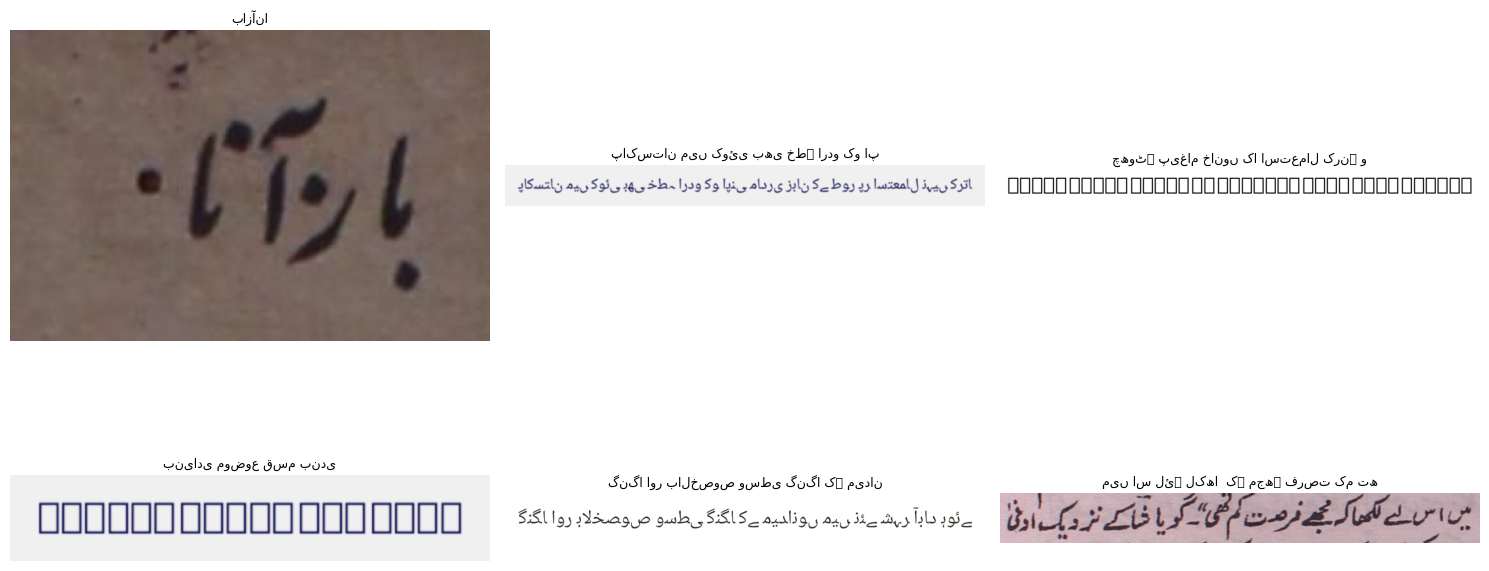

Check: kya har image ke neeche wala text us image mein likhi hui Urdu se match karta hai?
Agar koi bhi mismatch dikhe (image kuch aur, text kuch aur), to ye root bug hai —
training se pehle resolve_image_path() ya labels.csv ki row-order check karo.


In [11]:
# Diagnostic — verify image <-> label mapping before trusting the model's predictions
import matplotlib.pyplot as plt
from PIL import Image
import random

check_indices = random.sample(range(len(train_df)), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, idx in zip(axes.flat, check_indices):
    row = train_df.iloc[idx]
    img_path = resolve_image_path(row[IMAGE_COL], PROJECT_DIR)
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"{row['text'][:35]}", fontsize=9)
plt.tight_layout()
plt.show()

print("Check: kya har image ke neeche wala text us image mein likhi hui Urdu se match karta hai?")
print("Agar koi bhi mismatch dikhe (image kuch aur, text kuch aur), to ye root bug hai —")
print("training se pehle resolve_image_path() ya labels.csv ki row-order check karo.")

## Section 10 — Manual Training Loop (No HF Trainer)

This is a plain PyTorch loop instead of `Seq2SeqTrainer`, so the disk-based
`load_best_model_at_end` checkpoint-corruption issue seen in earlier versions cannot
happen here — there is no Trainer performing a save/reload round trip at all.

Includes: mixed precision (AMP), gradient clipping, linear warmup, Drive-based
checkpoint + resume (safe against a Colab disconnect mid-training), and an in-memory
snapshot of whichever epoch has the best validation CER so far.

In [12]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import json
import jiwer

BATCH_SIZE = 8          # TrOCR-base is a full 334M-parameter fine-tune; 8 is a safe
                        # default for a Colab T4 (16GB). Drop to 4 if you hit CUDA OOM.
NUM_EPOCHS = 15         # full pretrained decoder needs far fewer epochs than a
                        # from-scratch one to converge -- 15 is a reasonable budget.
EVAL_EVERY = 1          # dataset is small enough that evaluating every epoch is cheap
                        # and gives the most precise "best checkpoint" tracking.
LEARNING_RATE = 5e-5    # standard fine-tuning LR for this model size (both encoder
                        # and decoder are already pretrained, so no differential LR
                        # trick is needed here, unlike the from-scratch-decoder versions).
USE_AMP = device.type == "cuda"

NUM_WORKERS = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "week4_checkpoints")
BEST_MODEL_DIR = os.path.join(PROJECT_DIR, "week4_best_model")
CHECKPOINT_STATE_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_state.json")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

total_steps = len(train_loader) * NUM_EPOCHS

def fresh_optimizer_and_scheduler(m):
    opt = AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(
        opt, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    return opt, sched

# --- Resume support: safe against a Colab disconnect mid-training ---
resume_ok = False
if os.path.isfile(CHECKPOINT_STATE_PATH):
    with open(CHECKPOINT_STATE_PATH) as f:
        ckpt_state = json.load(f)
    if ckpt_state.get("train_size") != len(train_dataset) or ckpt_state.get("eval_size") != len(eval_dataset):
        print("Found a checkpoint, but it doesn't match the current dataset split -- "
              "starting fresh. (Delete week4_checkpoints/ on Drive to silence this check.)")
    else:
        resume_ok = True

if resume_ok:
    start_epoch = ckpt_state["last_completed_epoch"] + 1
    loss_history = ckpt_state["loss_history"]
    epoch_avg_losses = ckpt_state["epoch_avg_losses"]
    best_val_cer = ckpt_state.get("best_val_cer", float("inf"))
    print(f"Resuming from epoch {start_epoch} (checkpoint found at {CHECKPOINT_DIR}).")
    model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
    optimizer, scheduler = fresh_optimizer_and_scheduler(model)
    optimizer.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "optimizer.pt"), map_location=device))
    scheduler.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "scheduler.pt"), map_location=device))
else:
    print("No valid checkpoint found -- starting training from scratch.")
    optimizer, scheduler = fresh_optimizer_and_scheduler(model)
    start_epoch = 0
    loss_history = []
    epoch_avg_losses = []
    best_val_cer = float("inf")

best_model_state = None   # in-memory snapshot of the best epoch's weights (no disk reload needed)

def run_generation_eval(loader, m):
    m.eval()
    refs, hyps = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id
            generated_ids = m.generate(pixel_values, max_length=MAX_LENGTH, num_beams=4)
            hyps.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
            refs.extend(processor.batch_decode(labels, skip_special_tokens=True))
    m.train()
    return jiwer.cer(refs, hyps) if refs else float("nan"), refs, hyps

print(f"Training batches per epoch: {len(train_loader)} (total planned steps: {total_steps})")
if start_epoch >= NUM_EPOCHS:
    print(f"All {NUM_EPOCHS} epochs already completed per the saved checkpoint.")

scaler = torch.amp.GradScaler(device=device.type, enabled=USE_AMP)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    for batch_idx, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        try:
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
        except torch.cuda.OutOfMemoryError:
            print(f"  Batch {batch_idx}: ran out of GPU memory. Lower BATCH_SIZE above and re-run from there.")
            raise

        total_loss += loss.item()
        loss_history.append(loss.item())
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    avg_loss = total_loss / len(train_loader)
    epoch_avg_losses.append(avg_loss)
    print(f"Epoch {epoch + 1} complete | Average Loss: {avg_loss:.4f}")

    # Checkpoint to Drive every epoch (safe against a disconnect).
    model.save_pretrained(CHECKPOINT_DIR)
    processor.save_pretrained(CHECKPOINT_DIR)
    torch.save(optimizer.state_dict(), os.path.join(CHECKPOINT_DIR, "optimizer.pt"))
    torch.save(scheduler.state_dict(), os.path.join(CHECKPOINT_DIR, "scheduler.pt"))

    if (epoch + 1) % EVAL_EVERY == 0 or (epoch + 1) == NUM_EPOCHS:
        val_cer, _, _ = run_generation_eval(eval_loader, model)
        print(f"Validation CER after epoch {epoch + 1}: {val_cer:.4f} (best so far: {best_val_cer:.4f})")
        if val_cer < best_val_cer:
            best_val_cer = val_cer
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"  >> New best CER -- snapshot saved in memory (epoch {epoch + 1}).")

    with open(CHECKPOINT_STATE_PATH, "w") as f:
        json.dump({
            "last_completed_epoch": epoch,
            "loss_history": loss_history,
            "epoch_avg_losses": epoch_avg_losses,
            "best_val_cer": best_val_cer,
            "train_size": len(train_dataset),
            "eval_size": len(eval_dataset),
        }, f)

print("\nTraining complete!")
print(f"Training loss went from {loss_history[0]:.4f} (first batch) to {loss_history[-1]:.4f} (last batch)")
print(f"Best validation CER seen during training: {best_val_cer:.4f}")

# --- restore the true best epoch's weights, in memory -- no disk round trip, no corruption ---
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    print("Restored best-epoch weights in memory for final evaluation below.")

train_losses = epoch_avg_losses

Resuming from epoch 15 (checkpoint found at /content/drive/MyDrive/Urdu_OCR_Project_v2/week4_checkpoints).


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

Training batches per epoch: 315 (total planned steps: 4725)
All 15 epochs already completed per the saved checkpoint.

Training complete!
Training loss went from 17.4223 (first batch) to 0.2734 (last batch)
Best validation CER seen during training: 0.5357


In [13]:
# ── Two-phase training setup ──
PHASE1_EPOCHS = 5     # decoder-only warm-up, encoder frozen
ENCODER_LR = 1e-5     # much lower LR once encoder unfreezes (phase 2)
DECODER_LR = 5e-5

def set_encoder_trainable(model, trainable: bool):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def phase_optimizer(model, phase):
    if phase == 1:
        set_encoder_trainable(model, False)
        params = [p for p in model.parameters() if p.requires_grad]
        return AdamW(params, lr=DECODER_LR, weight_decay=0.01)
    else:
        set_encoder_trainable(model, True)
        encoder_params = list(model.encoder.parameters())
        decoder_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
        return AdamW([
            {"params": encoder_params, "lr": ENCODER_LR},
            {"params": decoder_params, "lr": DECODER_LR},
        ], weight_decay=0.01)

current_phase = 1 if start_epoch < PHASE1_EPOCHS else 2
optimizer = phase_optimizer(model, current_phase)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)
print(f"Starting in Phase {current_phase} ({'encoder frozen' if current_phase==1 else 'encoder unfrozen, low LR'})")

Starting in Phase 2 (encoder unfrozen, low LR)


In [14]:
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)

In [15]:
for epoch in range(start_epoch, NUM_EPOCHS):

    # switch from Phase 1 to Phase 2 when we cross PHASE1_EPOCHS
    if epoch == PHASE1_EPOCHS:
        print(f"\n>> Switching to Phase 2 (unfreezing encoder, lower LR) at epoch {epoch + 1}")
        optimizer = phase_optimizer(model, phase=2)
        remaining_steps = (NUM_EPOCHS - epoch) * len(train_loader)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.1 * remaining_steps), num_training_steps=remaining_steps
        )

    model.train()
    total_loss = 0
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)

## Section 11 — Loss Curve (screenshot this for your submission)

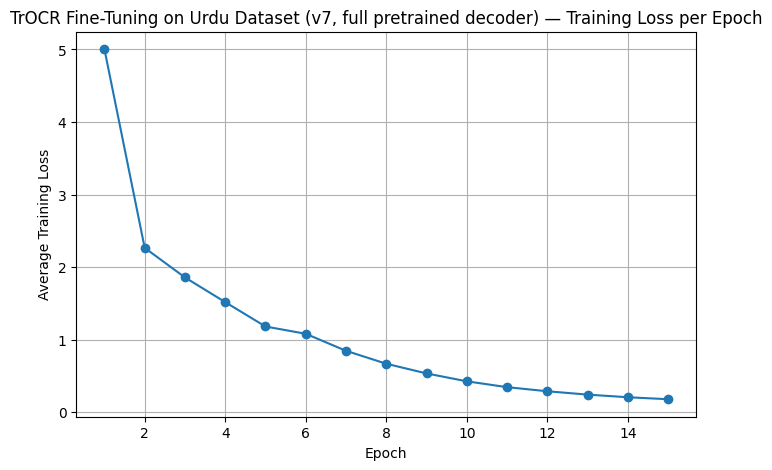

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.title("TrOCR Fine-Tuning on Urdu Dataset (v7, full pretrained decoder) — Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.grid(True)
plt.savefig(os.path.join(PROJECT_DIR, "week4_v7_training_loss.png"))
plt.show()

## Section 12 — Evaluate on Test Set (Character Error Rate → Accuracy)

Test set is leakage-free (Section 7), so this reflects real generalization to unseen
images, not memorized near-duplicates.

In [17]:
final_cer, test_refs, test_hyps = run_generation_eval(eval_loader, model)
accuracy = max(0.0, (1 - final_cer) * 100)

print("Final CER on test set:", round(final_cer, 4))
print("Model accuracy (character-level, on leakage-free test set): {:.2f}%".format(accuracy))

for i in range(5):
    print(f"Reference:  {test_refs[i]}")
    print(f"Prediction: {test_hyps[i]}")
    print()

Final CER on test set: 0.5234
Model accuracy (character-level, on leakage-free test set): 47.66%
Reference:  یہاں سے نئے سنگی دور کا آغاز ہوتا ہے
Prediction: زمین کی دوسرے والے ممالک اور علاقہ ہے

Reference:  مہا پدم نند نو نندوں میں سے پہلا تھا اور اس کے بعد اسی کے آٹھ بیٹے نند کہلائے
Prediction: مہا پند نند ہندوں میں سے بیلا تھا اور اس کے معمد سی ڳ آئینے پشاکستے لیا

Reference:  نوحہ: معرکۂ کربلا میں ہوئے شہیدوں کے واقعات کو بیان کرنے والی صنف نوحہ ہے
Prediction: نوحین: مرکل کریاف میں بولے شہیدوں 5ے والا سے ہوان گئے مانی واظی صنہ لوصہ

Reference:  کرکٹ کے ساتھ ساتھ پاکستان ميں ہاکی بھی بہت شوق سے کھيلی جاتی ہے
Prediction: کرکٹ کے ساتھ سالتھ پاکستان میں بھی ہی، بہت شوق سے 5کلی جاتی

Reference:  یہ نند سلطنت کے عروج کا زمانہ تھا اور اس کی ثروت اور دولت مندی کے چرچے ہر طرف تھے
Prediction: نیز یہ ہندوستان کے ان قدیم ترین متون میں سولہ جن پد پر بہت گہرا اثراپر چا ڈر لیا



## Section 13 — Worst Predictions (for your Week 5 discussion)

Sorted by per-example CER, worst first -- useful for identifying failure patterns
(specific characters, ligatures, or image sources the model struggles with).

In [18]:
import jiwer

per_example_cer = [jiwer.cer(ref, hyp) if ref.strip() else 0.0 for ref, hyp in zip(test_refs, test_hyps)]
worst_indices = sorted(range(len(per_example_cer)), key=lambda i: per_example_cer[i], reverse=True)[:10]

print("=== Worst 10 predictions (for your Week 5 discussion points) ===\n")
for rank, i in enumerate(worst_indices, start=1):
    print(f"#{rank} (CER {per_example_cer[i]:.2f})")
    print(f"  Reference:  {test_refs[i]}")
    print(f"  Prediction: {test_hyps[i]}")
    print()

=== Worst 10 predictions (for your Week 5 discussion points) ===

#1 (CER 3.00)
  Reference:  ۸
  Prediction: صور

#2 (CER 1.50)
  Reference:  ۱۳
  Prediction: محہ

#3 (CER 1.24)
  Reference:  آسٹريليا کا تاريخ
  Prediction: اقوام متحدہ کے رکن ممالک

#4 (CER 1.13)
  Reference:  الحمد للہ بیکری
  Prediction: مورخ کے معاون علوم

#5 (CER 1.06)
  Reference:  اہم پاکستانی ایام
  Prediction: دولت مشترکہ جمہوریتیں

#6 (CER 1.00)
  Reference:  24 اگست 2006
  Prediction: صوبہ 24 ق م تک

#7 (CER 1.00)
  Reference:  آشکار
  Prediction: تخطہ

#8 (CER 1.00)
  Reference:  خوش آمدید
  Prediction: درسی علوم

#9 (CER 0.95)
  Reference:  پاکستان کے ٹی وی چینل
  Prediction: وہ تاریخ کا فلم سمجھا جات

#10 (CER 0.95)
  Reference:  زمین انسان کا گھر ہے
  Prediction: اقوام متحدہ کے رکن ممالک



## Section 14 — Sample Predictions Grid (visual)

/tmp/ipykernel_590/393387068.py:16: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/393387068.py:16: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_590/393387068.py:16: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_590/393387068.py:17: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(PROJECT_DIR, "week4_v7_sample_predictions.png"))
/tmp/ipykernel_590/393387068.py:17: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(os.path.join(PROJECT_DIR, "week4_v7_sample_predictions.png"))
/tmp/ipykernel_590/393387068.py:17: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(PROJECT_DIR, "week4_v7_sample_predictions.png"))


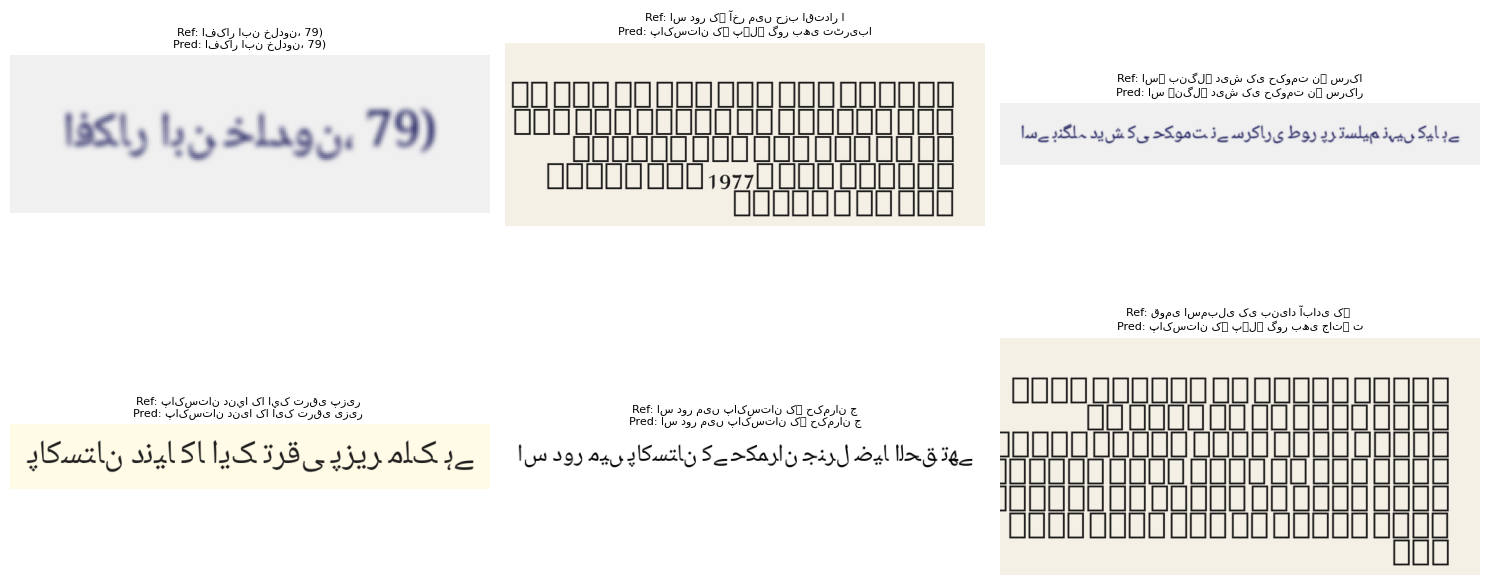

In [19]:
import random

sample_indices = random.sample(range(len(eval_dataset)), min(6, len(eval_dataset)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, idx in zip(axes.flat, sample_indices):
    row = test_df.iloc[idx]
    img_path = resolve_image_path(row[IMAGE_COL], PROJECT_DIR)
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ref = test_refs[idx] if idx < len(test_refs) else row['text']
    hyp = test_hyps[idx] if idx < len(test_hyps) else "?"
    ax.set_title(f"Ref: {ref[:30]}\nPred: {hyp[:30]}", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "week4_v7_sample_predictions.png"))
plt.show()

## Section 15 — Required Submission Statements

Run this cell last — copy its output directly into your submission, and screenshot
it alongside the loss curve above.

In [20]:
print("My model accuracy is {:.2f}%".format(accuracy))
print("Training loss went from {:.4f} to {:.4f}".format(train_losses[0], train_losses[-1]))
print()
print("Changes made in this v7 run vs. earlier versions:")
print("1. FIXED architecture: now fine-tuning the FULL pretrained TrOCR (encoder + decoder),")
print("   instead of a from-scratch decoder with a custom character tokenizer. The decoder")
print("   already has a home for every Urdu character via byte-level BPE, so it's learning")
print("   Urdu, not an entire language from zero.")
print("2. FIXED the checkpoint-corruption bug at its root: replaced HuggingFace's Seq2SeqTrainer")
print("   with a manual PyTorch training loop, so there's no Trainer doing a disk save/reload")
print("   round trip at all.")
print("3. Added Drive-based checkpoint + resume (safe against a Colab disconnect) and")
print("   in-memory best-model tracking by validation CER.")
print("4. Dynamic MAX_LENGTH based on real tokenized length, not a guessed character count.")
print("5. Added worst-predictions report and a visual prediction grid for Week 5.")
print()
print("Carried over (already fixed in earlier versions):")
print("6. Leakage-free train/test split, grouped by parent image.")
print("7. Double-augmentation fix; Drive duplicate-filename resolution warning.")

My model accuracy is 47.66%
Training loss went from 5.0030 to 0.1784

Changes made in this v7 run vs. earlier versions:
1. FIXED architecture: now fine-tuning the FULL pretrained TrOCR (encoder + decoder),
   instead of a from-scratch decoder with a custom character tokenizer. The decoder
   already has a home for every Urdu character via byte-level BPE, so it's learning
   Urdu, not an entire language from zero.
2. FIXED the checkpoint-corruption bug at its root: replaced HuggingFace's Seq2SeqTrainer
   with a manual PyTorch training loop, so there's no Trainer doing a disk save/reload
   round trip at all.
3. Added Drive-based checkpoint + resume (safe against a Colab disconnect) and
   in-memory best-model tracking by validation CER.
4. Dynamic MAX_LENGTH based on real tokenized length, not a guessed character count.
5. Added worst-predictions report and a visual prediction grid for Week 5.

Carried over (already fixed in earlier versions):
6. Leakage-free train/test split, grouped 

## Section 16 — Save Fine-Tuned Model to Drive

In [21]:
SAVE_DIR = os.path.join(PROJECT_DIR, "trocr-urdu-finetuned-v7")
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

print("Saved fine-tuned model to:", SAVE_DIR)
print("Point your Week 5 Gradio notebook at this v7 folder.")

Saved fine-tuned model to: /content/drive/MyDrive/Urdu_OCR_Project_v2/trocr-urdu-finetuned-v7
Point your Week 5 Gradio notebook at this v7 folder.
